# GPU YouTube corpus - main analysis notebook

## Data load and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

np.random.seed(111)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 160)

from pathlib import Path

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
ROOT = None
for cand in ROOT_CANDIDATES:
    if (cand / "data-processed").exists() or (cand / "data-clean").exists():
        ROOT = cand
        break
if ROOT is None:
    ROOT = Path.cwd()

DATA_PROCESSED_DEFAULT = ROOT / "data-processed"
FALLBACK_DATA_DIR = ROOT / "data-clean"

DATA_PROCESSED = DATA_PROCESSED_DEFAULT if DATA_PROCESSED_DEFAULT.exists() else FALLBACK_DATA_DIR
if not (DATA_PROCESSED / "comments.parquet").exists():
    DATA_PROCESSED = FALLBACK_DATA_DIR

FIG_DIR = ROOT / "figures"

comments_parquet = DATA_PROCESSED / "comments.parquet"
transcripts_parquet = DATA_PROCESSED / "transcripts.parquet"
videos_parquet = DATA_PROCESSED / "videos.parquet"
corpus_parquet = DATA_PROCESSED / "corpus.parquet"

def load_data():
    """Read all core parquet tables."""
    comments = pd.read_parquet(comments_parquet)
    transcripts = pd.read_parquet(transcripts_parquet)
    videos = pd.read_parquet(videos_parquet)
    corpus = pd.read_parquet(corpus_parquet)
    return comments, transcripts, videos, corpus

comments_df, transcripts_df, videos_df, corpus_df = load_data()
data_frames = {
    "comments": comments_df,
    "transcripts": transcripts_df,
    "videos": videos_df,
    "corpus": corpus_df,
}

summary_stats = {
    "video_count": len(videos_df),
    "total_comments": len(comments_df),
    "total_transcript_segments": len(transcripts_df),
}

## Data peek

In [2]:
def unique_video_ids(df):
    return df['video_id'].nunique() if 'video_id' in df.columns else np.nan

for name, df in data_frames.items():
    vid_count = unique_video_ids(df)
    print(f"{name}: shape={df.shape}, distinct video_id={vid_count}")

comments: shape=(762642, 9), distinct video_id=330
transcripts: shape=(307694, 6), distinct video_id=325
videos: shape=(330, 32), distinct video_id=330
corpus: shape=(1070336, 13), distinct video_id=330


## Basic sanity checks

In [3]:
def empty_text_stats(df, name):
    if 'text' not in df.columns:
        print(f"{name}: no text column to check.")
        return
    text_series = df['text'].fillna("").astype(str)
    empty_mask = text_series.str.strip().eq("")
    count = int(empty_mask.sum())
    pct = (count / len(df) * 100) if len(df) else 0
    print(f"{name}: empty/whitespace text = {count} rows ({pct:.2f}%)")

empty_text_stats(comments_df, "comments_df")
empty_text_stats(corpus_df, "corpus_df")

if {'video_id', 'comment_id'}.issubset(comments_df.columns):
    dup_pairs = int(comments_df.duplicated(subset=['video_id', 'comment_id']).sum())
else:
    dup_pairs = 0
dup_text = int(comments_df.duplicated(subset=['video_id', 'text']).sum())
print(f"comments_df: duplicate (video_id, comment_id) pairs = {dup_pairs}")
print(f"comments_df: duplicate (video_id, text) pairs = {dup_text}")

comments_df: empty/whitespace text = 0 rows (0.00%)
corpus_df: empty/whitespace text = 0 rows (0.00%)
comments_df: duplicate (video_id, comment_id) pairs = 0
comments_df: duplicate (video_id, text) pairs = 6070


In [4]:
def preview_df(df, name, head_n=5):
    print(f"--- {name} ---")
    display(df.head(head_n))
    print(df.dtypes)
    print()

for name, df in data_frames.items():
    preview_df(df, name)

--- comments ---


,video_id,comment_id,parent_id,author,text,like_count,published_at,is_reply,raw_path
0,-LAH5vh-Cpg,UgwLD6mOcKzW7uydecl4AaABAg,None,@wizzardrincewind9458,👍🖖,NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json
1,-LAH5vh-Cpg,UgwOpxeGdV-UzJh24S54AaABAg,None,@one2manyhobbies956,After having my 9060xt 16gb I'm very happy wit...,NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json
2,-LAH5vh-Cpg,Ugw-asbj9qmOkM1UUdd4AaABAg,None,@WillFuI,For the cost per frame don’t u want lower is b...,NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json
3,-LAH5vh-Cpg,UgyQs9cIWFH49EYU1yZ4AaABAg,None,@xitachi_da_goatx9975,I just got my 9060xt after going back and fort...,NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json
4,-LAH5vh-Cpg,UgzMh9kuWmIgR6gUeCt4AaABAg,None,@srobeck77,"If you bought the 8gb version in 2025, slap yo...",NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json


video_id                     object
comment_id                   object
parent_id                    object
author                       object
text                         object
like_count                  float64
published_at    datetime64[ns, UTC]
is_reply                       bool
raw_path                     object
dtype: object

--- transcripts ---


,video_id,lang,start_seconds,end_seconds,text,raw_path
0,-LAH5vh-Cpg,en,5.0,5.0,[Music],data-raw\transcripts\-LAH5vh-Cpg.en.vtt
1,-LAH5vh-Cpg,en,5.0,8.0,[Music]\nToday we're reviewing AMD's new Radeon,data-raw\transcripts\-LAH5vh-Cpg.en.vtt
2,-LAH5vh-Cpg,en,8.0,8.0,Today we're reviewing AMD's new Radeon,data-raw\transcripts\-LAH5vh-Cpg.en.vtt
3,-LAH5vh-Cpg,en,8.0,13.0,Today we're reviewing AMD's new Radeon\nRX 960...,data-raw\transcripts\-LAH5vh-Cpg.en.vtt
4,-LAH5vh-Cpg,en,13.0,13.0,RX 960 XT which is available in 8 and 16,data-raw\transcripts\-LAH5vh-Cpg.en.vtt


video_id          object
lang              object
start_seconds    float64
end_seconds      float64
text              object
raw_path          object
dtype: object

--- videos ---


,video_id,title,uploader,channel,channel_id,duration,view_count,like_count,comment_count,categories,tags,available_captions,upload_date,webpage_url,info_path,timestamp,manifest_video_id,manifest_url,manifest_gpu_model,manifest_brand,manifest_video_title,manifest_status_comments,manifest_status_transcripts,manifest_comments_path,manifest_transcripts_dir,manifest_info_path,manifest_error_message,manifest_started_at,manifest_finished_at,manifest_elapsed_sec,manifest_num_transcript_files,release_timestamp
0,-LAH5vh-Cpg,"AMD Radeon RX 9060 XT 16GB Review, Gaming Benc...",Hardware Unboxed,Hardware Unboxed,UCI8iQa1hv7oV_Z8D35vVuSg,1371,336623,13277,1714,Science & Technology,hardware unboxed,None,2025-06-04 00:00:00+00:00,https://www.youtube.com/watch?v=-LAH5vh-Cpg,data-raw\info\-LAH5vh-Cpg.info.json,2025-06-04 13:00:01+00:00,-LAH5vh-Cpg,https://www.youtube.com/watch?v=-LAH5vh-Cpg,Radeon RX 9060 XT,AMD,"AMD Radeon RX 9060 XT 16GB Review, Gaming Benc...",ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:55:46.829820+00:00,2025-11-04 18:55:46.838021+00:00,0.01,1,NaT
1,-Lcyyl2kQL8,AMD RX 5600 XT Review – Gaming & Overclocking,optimum,optimum,UCRYOj4DmyxhBVrdvbsUwmAA,571,108206,2572,185,Science & Technology,"AMD,RX 5600 XT,Review,Benchmarks,Test,gaming,p...",None,2020-01-21 00:00:00+00:00,https://www.youtube.com/watch?v=-Lcyyl2kQL8,data-raw\info\-Lcyyl2kQL8.info.json,2020-01-21 14:00:50+00:00,-Lcyyl2kQL8,https://www.youtube.com/watch?v=-Lcyyl2kQL8,Radeon RX 5600 XT,AMD,AMD RX 5600 XT Review – Gaming & Overclocking,ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:53:24.089112+00:00,2025-11-04 18:53:24.091453+00:00,0.00,1,NaT
2,-M1bMzVzZF0,The Intel Arc B580: Midrange GPU Magic!,Level1Techs,Level1Techs,UC4w1YQAJMWOz4qtxinq55LQ,1691,131977,5728,739,Science & Technology,"technology,science,design,ux,computers,hardwar...",None,2024-12-12 00:00:00+00:00,https://www.youtube.com/watch?v=-M1bMzVzZF0,data-raw\info\-M1bMzVzZF0.info.json,2024-12-12 14:08:28+00:00,-M1bMzVzZF0,https://www.youtube.com/watch?v=-M1bMzVzZF0,Arc A580,INTEL,The Intel Arc B580: Midrange GPU Magic!,ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:57:03.334429+00:00,2025-11-04 18:57:03.338115+00:00,0.00,1,NaT
3,-PtTUnj4od4,AMD 6900XT... Something isn’t right...,JayzTwoCents,JayzTwoCents,UCkWQ0gDrqOCarmUKmppD7GQ,1160,923401,38391,5170,Science & Technology,"amd,big navi,is big navi worth it,is big navi ...",None,2020-12-08 00:00:00+00:00,https://www.youtube.com/watch?v=-PtTUnj4od4,data-raw\info\-PtTUnj4od4.info.json,2020-12-08 14:00:01+00:00,-PtTUnj4od4,https://www.youtube.com/watch?v=-PtTUnj4od4,Radeon RX 6900 XT,AMD,AMD 6900XT... Something isn’t right…,ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:54:24.530558+00:00,2025-11-04 18:54:24.555183+00:00,0.02,1,NaT
4,-SAWtKEIYbw,"AMD Radeon RX 5700 XT Review: Thermals, Noise,...",Gamers Nexus,Gamers Nexus,UChIs72whgZI9w6d6FhwGGHA,1794,453926,11178,2145,Gaming,"gamersnexus,gamers nexus,computer hardware,amd...",None,2019-07-07 00:00:00+00:00,https://www.youtube.com/watch?v=-SAWtKEIYbw,data-raw\info\-SAWtKEIYbw.info.json,2019-07-07 16:30:00+00:00,-SAWtKEIYbw,https://www.youtube.com/watch?v=-SAWtKEIYbw,Radeon RX 5700 XT,AMD,"AMD Radeon RX 5700 XT Review: Thermals, Noise,...",ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:53:42.337517+00:00,2025-11-04 18:53:42.346630+00:00,0.01,1,NaT


video_id                                      object
title                                         object
uploader                                      object
channel                                       object
channel_id                                    object
                                        ...         
manifest_started_at              datetime64[ns, UTC]
manifest_finished_at             datetime64[ns, UTC]
manifest_elapsed_sec                         float64
manifest_num_transcript_files                  int64
release_timestamp                datetime64[ns, UTC]
Length: 32, dtype: object

--- corpus ---


,video_id,text,timestamp,source_type,comment_id,parent_id,author,like_count,is_reply,raw_path,lang,start_seconds,end_seconds
0,-LAH5vh-Cpg,👍🖖,NaT,comment,UgwLD6mOcKzW7uydecl4AaABAg,None,@wizzardrincewind9458,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN
1,-LAH5vh-Cpg,After having my 9060xt 16gb I'm very happy wit...,NaT,comment,UgwOpxeGdV-UzJh24S54AaABAg,None,@one2manyhobbies956,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN
2,-LAH5vh-Cpg,For the cost per frame don’t u want lower is b...,NaT,comment,Ugw-asbj9qmOkM1UUdd4AaABAg,None,@WillFuI,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN
3,-LAH5vh-Cpg,I just got my 9060xt after going back and fort...,NaT,comment,UgyQs9cIWFH49EYU1yZ4AaABAg,None,@xitachi_da_goatx9975,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN
4,-LAH5vh-Cpg,"If you bought the 8gb version in 2025, slap yo...",NaT,comment,UgzMh9kuWmIgR6gUeCt4AaABAg,None,@srobeck77,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN


video_id                      object
text                          object
timestamp        datetime64[ns, UTC]
source_type                   object
comment_id                    object
parent_id                     object
author                        object
like_count                   float64
is_reply                      object
raw_path                      object
lang                          object
start_seconds                float64
end_seconds                  float64
dtype: object



## Scale descriptive stats

In [5]:
video_duration_col = 'duration_sec' if 'duration_sec' in videos_df.columns else 'duration'
total_video_seconds = videos_df[video_duration_col].fillna(0).astype(float).sum()
total_video_hours = total_video_seconds / 3600
summary_stats['total_video_hours'] = total_video_hours

if 'duration_sec' in transcripts_df.columns:
    transcript_duration = transcripts_df['duration_sec'].fillna(0)
else:
    transcript_duration = (transcripts_df['end_seconds'].fillna(0) - transcripts_df['start_seconds'].fillna(0)).clip(lower=0)
transcript_hours = transcript_duration.sum() / 3600
summary_stats['caption_hours'] = transcript_hours

def approx_word_count(series):
    return int(series.fillna("").str.strip().str.split().str.len().sum())

total_corpus_words = approx_word_count(corpus_df['text'])
comment_words = approx_word_count(corpus_df.loc[corpus_df['source_type'] == 'comment', 'text'])
transcript_words = approx_word_count(corpus_df.loc[corpus_df['source_type'] == 'transcript', 'text'])
WAR_AND_PEACE_WORDS = 600_000
war_peace_multiple = total_corpus_words / WAR_AND_PEACE_WORDS if WAR_AND_PEACE_WORDS else np.nan

summary_stats.update({
    'total_corpus_words': total_corpus_words,
    'comment_words': comment_words,
    'transcript_words': transcript_words,
    'war_peace_multiple': war_peace_multiple,
})

print(f"Total video hours (approx): {total_video_hours:,.2f}h")
print(f"Caption hours (transcripts): {transcript_hours:,.2f}h")
print(f"Total corpus words: {total_corpus_words:,}")
print(f"Comment words: {comment_words:,}; Transcript words: {transcript_words:,}")
print(f"Corpus vs War and Peace (600k words): {war_peace_multiple:,.2f}x")

total_comments = len(comments_df)
comments_per_video = comments_df.groupby('video_id').size().rename('comment_count')
comments_per_video_mean = comments_per_video.mean()
comments_per_video_median = comments_per_video.median()
summary_stats['comments_per_video_mean'] = comments_per_video_mean
summary_stats['comments_per_video_median'] = comments_per_video_median

view_counts = videos_df[['video_id', 'view_count']].dropna()
view_counts = view_counts[view_counts['view_count'] > 0]
merged_comments_views = comments_per_video.to_frame().join(view_counts.set_index('video_id'), how='inner')
merged_comments_views['comments_per_1k_views'] = merged_comments_views['comment_count'] / (merged_comments_views['view_count'] / 1000)
comments_per_1k_mean = merged_comments_views['comments_per_1k_views'].mean()
comments_per_1k_median = merged_comments_views['comments_per_1k_views'].median()

summary_stats.update({
    'total_comments': total_comments,
    'comments_per_1k_views_mean': comments_per_1k_mean,
    'comments_per_1k_views_median': comments_per_1k_median,
})

print(f"Total comments: {total_comments:,}")
print(f"Comments per video - mean: {comments_per_video_mean:,.2f}, median: {comments_per_video_median:,.2f}")
print(f"Comments per 1k views - mean: {comments_per_1k_mean:,.2f}, median: {comments_per_1k_median:,.2f}")

Total video hours (approx): 101.36h
Caption hours (transcripts): 101.77h
Total corpus words: 23,640,046
Comment words: 20,420,835; Transcript words: 3,219,211
Corpus vs War and Peace (600k words): 39.40x
Total comments: 762,642
Comments per video - mean: 2,311.04, median: 1,459.00
Comments per 1k views - mean: 5.11, median: 4.49


## Coverage and quick distributions (no plots)

In [6]:
videos_with_transcripts = transcripts_df['video_id'].nunique() if 'video_id' in transcripts_df.columns else 0
total_videos = len(videos_df)
videos_without_transcripts = max(total_videos - videos_with_transcripts, 0)
coverage_pct = (videos_with_transcripts / total_videos * 100) if total_videos else 0
zero_segments_pct = (videos_without_transcripts / total_videos * 100) if total_videos else 0
summary_stats['transcript_coverage_pct'] = coverage_pct

print(f"Videos with transcripts: {videos_with_transcripts} / {total_videos} ({coverage_pct:.2f}%)")
print(f"Videos with zero transcript segments: {videos_without_transcripts} / {total_videos} ({zero_segments_pct:.2f}%)")

lang_counts = transcripts_df['lang'].value_counts().head(10) if 'lang' in transcripts_df.columns else pd.Series(dtype=int)
summary_stats['top_langs'] = lang_counts
print("Top transcript languages (top 10):")
print(lang_counts)

comment_chars = comments_df['text'].fillna("").str.len()
comment_words_len = comments_df['text'].fillna("").str.split().str.len()

def describe_series(series):
    return {
        'mean': series.mean(),
        'median': series.median(),
        'p95': series.quantile(0.95),
    }

comment_char_desc = describe_series(comment_chars)
comment_word_desc = describe_series(comment_words_len)

transcript_duration = transcript_duration if 'transcript_duration' in globals() else (transcripts_df['end_seconds'].fillna(0) - transcripts_df['start_seconds'].fillna(0)).clip(lower=0)
transcript_duration_desc = describe_series(transcript_duration)

print("Comment length (chars):", comment_char_desc)
print("Comment length (words):", comment_word_desc)
print("Transcript segment duration (sec):", transcript_duration_desc)

Videos with transcripts: 325 / 330 (98.48%)
Videos with zero transcript segments: 5 / 330 (1.52%)
Top transcript languages (top 10):
lang
en       303884
en-US      3810
Name: count, dtype: int64
Comment length (chars): {'mean': np.float64(142.8788028983455), 'median': 86.0, 'p95': np.float64(448.0)}
Comment length (words): {'mean': np.float64(26.77643638823983), 'median': 16.0, 'p95': np.float64(83.0)}
Transcript segment duration (sec): {'mean': np.float64(1.1907512008683951), 'median': 1.0, 'p95': np.float64(3.0)}


## Summary

In [7]:
war_and_peace_equiv = summary_stats.get('war_peace_multiple', np.nan)
top_langs = summary_stats.get('top_langs', pd.Series(dtype=int))
lang_summary = ", ".join([f"{lang} ({count})" for lang, count in top_langs.items()])

summary_lines = [
    f"Videos: {summary_stats.get('video_count', 0):,}",
    f"Total comments: {summary_stats.get('total_comments', 0):,}",
    f"Transcript segments: {summary_stats.get('total_transcript_segments', 0):,}",
    f"Video hours vs caption hours: {summary_stats.get('total_video_hours', 0):,.2f}h vs {summary_stats.get('caption_hours', 0):,.2f}h",
    f"Corpus words: {summary_stats.get('total_corpus_words', 0):,} (~{war_and_peace_equiv:,.2f}x War and Peace)",
    f"Comment vs transcript words: {summary_stats.get('comment_words', 0):,} / {summary_stats.get('transcript_words', 0):,}",
    f"Transcript coverage: {summary_stats.get('transcript_coverage_pct', 0):.2f}%",
    f"Languages: {lang_summary}",
]

summary_md = "\n".join([f"- {line}" for line in summary_lines])
display(Markdown(summary_md))

- Videos: 330
- Total comments: 762,642
- Transcript segments: 307,694
- Video hours vs caption hours: 101.36h vs 101.77h
- Corpus words: 23,640,046 (~39.40x War and Peace)
- Comment vs transcript words: 20,420,835 / 3,219,211
- Transcript coverage: 98.48%
- Languages: en (303884), en-US (3810)

## Stage 2 - Visual EDA and grouped statistics

In [8]:
def safe_month_floor(datetime_series):
    dt = pd.to_datetime(datetime_series, errors="coerce", utc=True)
    dt = dt.dt.tz_convert(None)
    return dt.dt.to_period("M").dt.to_timestamp()


def approx_word_count(series):
    return int(series.fillna("").str.strip().str.split().str.len().sum())

### Distributions - comments and transcripts

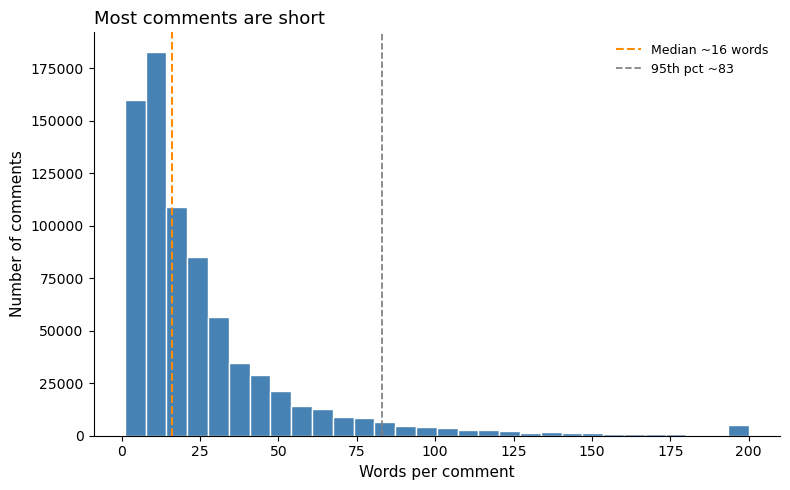

In [9]:
comment_text = comments_df['text'].fillna("")
comment_words = comment_text.str.split().str.len().clip(upper=200)
comment_chars = comment_text.str.len().clip(upper=2000)

median_words = comment_words.median()
p95_words = comment_words.quantile(0.95)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(comment_words, bins=30, color="steelblue", edgecolor="white")
ax.set_title("Most comments are short", fontsize=13, loc='left')
ax.set_xlabel("Words per comment", fontsize=11)
ax.set_ylabel("Number of comments", fontsize=11)
ax.tick_params(labelsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.axvline(median_words, color='darkorange', linestyle='--', linewidth=1.5, label=f"Median ~{median_words:.0f} words")
ax.axvline(p95_words, color='gray', linestyle='--', linewidth=1.25, label=f"95th pct ~{p95_words:.0f}")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "comments_length_words_hist.png", dpi=150)
plt.show()

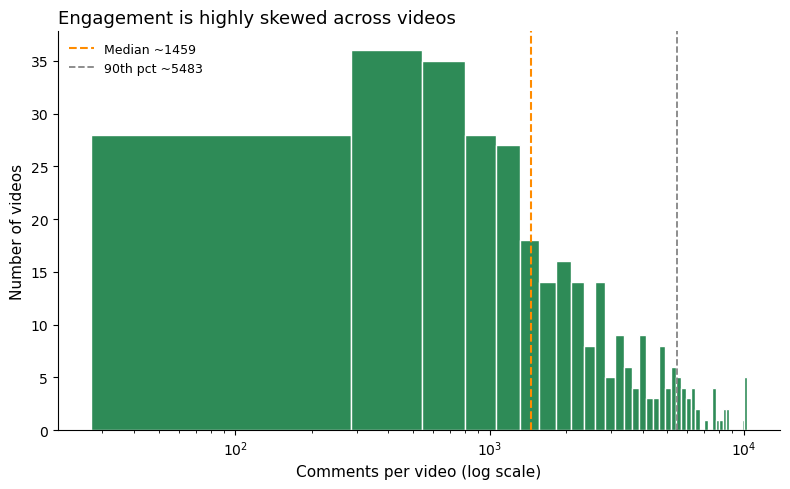

In [10]:
comments_per_video = comments_df.groupby('video_id').size().rename('comment_count')
comments_per_video_clipped = comments_per_video.clip(upper=comments_per_video.quantile(0.99))

median_comments = comments_per_video.median()
p90_comments = comments_per_video.quantile(0.90)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(comments_per_video_clipped, bins=40, color='seagreen', edgecolor='white')
ax.set_title('Engagement is highly skewed across videos', fontsize=13, loc='left')
ax.set_xlabel('Comments per video (log scale)', fontsize=11)
ax.set_ylabel('Number of videos', fontsize=11)
ax.tick_params(labelsize=10)
ax.set_xscale('log')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.axvline(median_comments, color='darkorange', linestyle='--', linewidth=1.5, label=f"Median ~{median_comments:.0f}")
ax.axvline(p90_comments, color='gray', linestyle='--', linewidth=1.25, label=f"90th pct ~{p90_comments:.0f}")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'comments_per_video_hist.png', dpi=150)
plt.show()

### Time series: activity over time

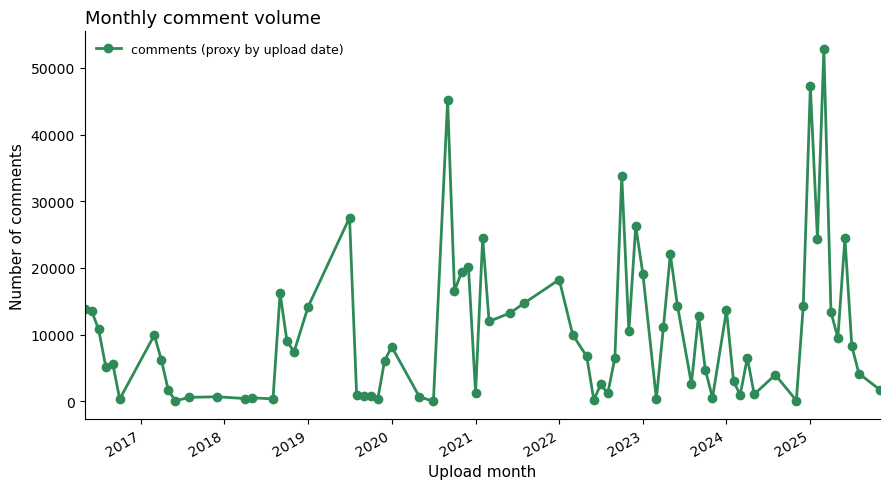

In [11]:
video_ts_col = None
for cand in ['upload_date', 'publish_date_utc', 'release_timestamp', 'timestamp', 'timestamp_utc']:
    if cand in videos_df.columns:
        video_ts_col = cand
        break

if video_ts_col is None:
    print('No usable upload timestamp in videos_df; skipping monthly time series plots.')
else:
    comments_with_video = comments_df.merge(videos_df[['video_id', video_ts_col]], on='video_id', how='left')
    comments_with_video['month'] = safe_month_floor(comments_with_video[video_ts_col])
    monthly_comments = (comments_with_video
                        .dropna(subset=['month'])
                        .groupby('month')
                        .size()
                        .rename('num_comments')
                        .reset_index())
    monthly_comments = monthly_comments.sort_values('month')

    if monthly_comments.empty:
        print('No proxy month data available to plot.')
    else:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(monthly_comments['month'], monthly_comments['num_comments'], marker='o', color='seagreen', linewidth=2, label='comments (proxy by upload date)')
        ax.set_title('Monthly comment volume', fontsize=13, loc='left')
        ax.set_xlabel('Upload month', fontsize=11)
        ax.set_ylabel('Number of comments', fontsize=11)
        ax.tick_params(labelsize=10)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.legend(frameon=False, fontsize=9)
        fig.autofmt_xdate()
        ax.set_xlim(monthly_comments['month'].min(), monthly_comments['month'].max())
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'docs_per_month_by_source.png', dpi=150)
        plt.show()

### GPU model / brand breakdown

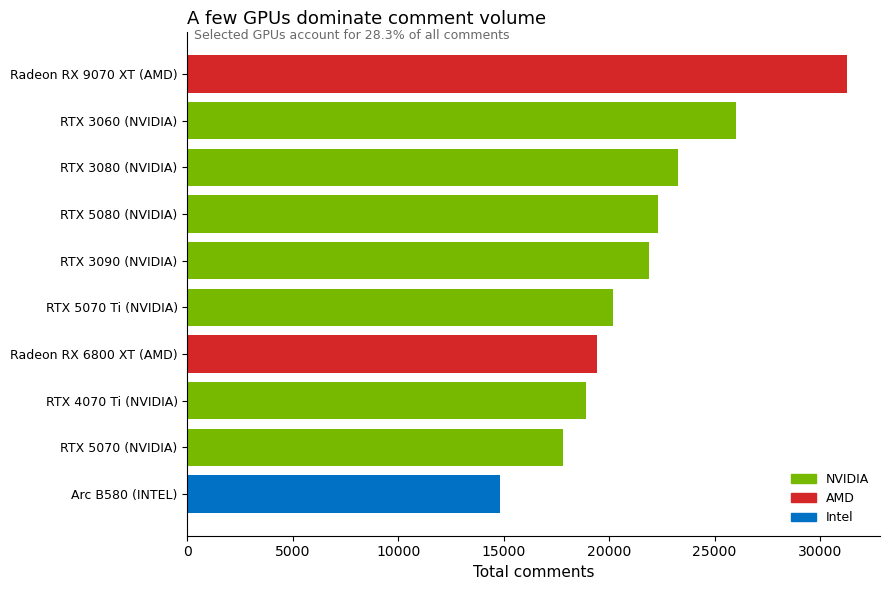

In [12]:
model_col = 'manifest_gpu_model' if 'manifest_gpu_model' in videos_df.columns else 'gpu_model'
brand_col = 'manifest_brand' if 'manifest_brand' in videos_df.columns else None

if model_col not in videos_df.columns:
    print('No GPU model column available; skipping top models chart.')
else:
    comment_counts_by_video = comments_df.groupby('video_id').size().rename('total_comments')
    model_df = videos_df[['video_id', model_col]].copy()
    if brand_col and brand_col in videos_df.columns:
        model_df['brand'] = videos_df[brand_col]
    else:
        model_df['brand'] = None

    model_df = model_df.join(comment_counts_by_video, on='video_id')
    model_df['total_comments'] = model_df['total_comments'].fillna(0)
    model_df = model_df.dropna(subset=[model_col])

    agg_models = (model_df
                  .groupby([model_col, 'brand'])
                  .agg(total_comments=('total_comments', 'sum'))
                  .reset_index())
    agg_models = agg_models.sort_values('total_comments', ascending=False)

    top9 = agg_models.head(9)

    intel_filter = (agg_models['brand'].str.lower() == 'intel') if 'brand' in agg_models.columns else False
    intel_rows = agg_models[intel_filter]
    top_intel = None
    if not intel_rows.empty:
        top_intel = intel_rows.head(1)
    else:
        contains_intel = agg_models[agg_models[model_col].str.contains('Intel', case=False, na=False)]
        if not contains_intel.empty:
            top_intel = contains_intel.head(1)
    if top_intel is None or top_intel.empty:
        top_intel = pd.DataFrame([{model_col: 'Intel GPU (no data)', 'brand': 'Intel', 'total_comments': 0}])

    combined = pd.concat([top9, top_intel]).drop_duplicates(subset=[model_col, 'brand'], keep='first')
    combined = combined.sort_values('total_comments', ascending=True)  # for barh

    if combined.empty:
        print('No model comment data available for plotting.')
    else:
        total_all = agg_models['total_comments'].sum()
        combined_share = (combined['total_comments'].sum() / total_all * 100) if total_all else 0

        def make_label(row):
            brand = row['brand'] if pd.notna(row['brand']) and row['brand'] not in (None, '') else None
            return f"{row[model_col]} ({brand})" if brand else f"{row[model_col]}"

        combined['label'] = combined.apply(make_label, axis=1)
        color_map = {'nvidia': '#76b900', 'amd': '#d62728', 'intel': '#0071c5'}
        combined['brand_clean'] = combined['brand'].str.lower().fillna('')
        combined['bar_color'] = combined['brand_clean'].map(color_map).fillna('gray')

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(combined['label'], combined['total_comments'], color=combined['bar_color'])
        ax.set_title('A few GPUs dominate comment volume', fontsize=13, loc='left')
        ax.set_xlabel('Total comments', fontsize=11)
        subtitle = f"Selected GPUs account for {combined_share:.1f}% of all comments"
        ax.text(0.01, 0.98, subtitle, transform=ax.transAxes, ha='left', va='bottom', fontsize=9, color='dimgray')
        ax.tick_params(axis='y', labelsize=9)
        ax.tick_params(axis='x', labelsize=10)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map['nvidia'], label='NVIDIA'),
                          plt.Rectangle((0, 0), 1, 1, color=color_map['amd'], label='AMD'),
                          plt.Rectangle((0, 0), 1, 1, color=color_map['intel'], label='Intel')]
        ax.legend(handles=legend_handles, frameon=False, fontsize=9, loc='lower right')

        fig.tight_layout()
        fig.savefig(FIG_DIR / 'top_gpu_models_comments_bar.png', dpi=150)
        plt.show()

### Time-series notes (proxy by upload date)

- Months are derived from video upload dates and applied to comments as a proxy (comment timestamps missing).
- Single-line plot shows comment volume per month; peaks correspond to upload-heavy months.
- Generational/group breakdown shows which GPU lines attract the most comments (see bar chart).

### Comments by GPU generation

,group,gen_total_comments,gen_num_videos,brand
66,Radeon RX 9070 XT,31276,10,AMD
19,RTX 3060,26001,5,NVIDIA
23,RTX 3080,23260,5,NVIDIA
41,RTX 5080,22334,5,NVIDIA
25,RTX 3090,21884,5,NVIDIA
40,RTX 5070 Ti,20193,5,NVIDIA
56,Radeon RX 6800 XT,19406,5,AMD
31,RTX 4070 Ti,18893,3,NVIDIA
39,RTX 5070,17828,5,NVIDIA
42,RTX 5090,17187,5,NVIDIA


C:\Users\Matthew\AppData\Local\Temp\ipykernel_10928\2091722522.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_gen_top['brand_clean'] = agg_gen_top['brand'].str.lower() if 'brand' in agg_gen_top.columns else ''
C:\Users\Matthew\AppData\Local\Temp\ipykernel_10928\2091722522.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_gen_top['bar_color'] = agg_gen_top['brand_clean'].map(color_map).fillna('gray') if 'brand_clean' in agg_gen_top.columns else 'steelblue'


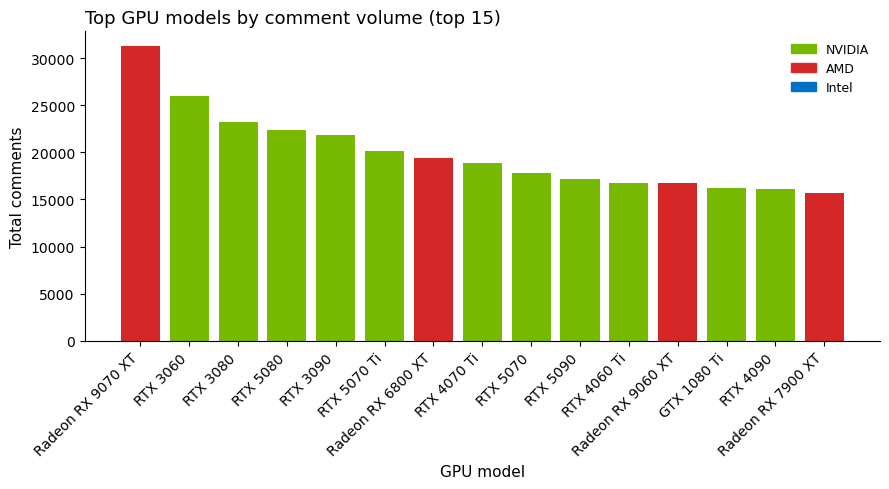

In [13]:
model_col = None
for cand in ['manifest_gpu_model', 'gpu_model']:
    if cand in videos_df.columns:
        model_col = cand
        break

brand_col = None
for cand in ['manifest_brand', 'brand']:
    if cand in videos_df.columns:
        brand_col = cand
        break

if model_col is None:
    print('No gpu_model column available; skipping model-level chart.')
else:
    comment_counts_by_video = comments_df.groupby('video_id').size().rename('total_comments')
    videos_with_comments = videos_df[['video_id']].copy()
    videos_with_comments['group'] = videos_df[model_col]
    if brand_col:
        videos_with_comments['brand'] = videos_df[brand_col]
    videos_with_comments = videos_with_comments.join(comment_counts_by_video, on='video_id')
    videos_with_comments['total_comments'] = videos_with_comments['total_comments'].fillna(0)

    videos_with_comments = videos_with_comments.dropna(subset=['group'])
    if videos_with_comments.empty:
        print('No model data available; skipping chart.')
    else:
        agg_gen = (videos_with_comments
                   .groupby('group')
                   .agg(gen_total_comments=('total_comments', 'sum'),
                        gen_num_videos=('video_id', 'nunique'))
                   .reset_index())
        if brand_col:
            brand_mode = (videos_with_comments
                          .groupby('group')['brand']
                          .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None)
                          .rename('brand'))
            agg_gen = agg_gen.merge(brand_mode, on='group', how='left')
        agg_gen = agg_gen.sort_values('gen_total_comments', ascending=False)

        agg_gen_top = agg_gen.head(15)

        display(agg_gen_top)

        color_map = {'nvidia': '#76b900', 'amd': '#d62728', 'intel': '#0071c5'}
        agg_gen_top['brand_clean'] = agg_gen_top['brand'].str.lower() if 'brand' in agg_gen_top.columns else ''
        agg_gen_top['bar_color'] = agg_gen_top['brand_clean'].map(color_map).fillna('gray') if 'brand_clean' in agg_gen_top.columns else 'steelblue'

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.bar(agg_gen_top['group'], agg_gen_top['gen_total_comments'], color=agg_gen_top['bar_color'])
        ax.set_title('Top GPU models by comment volume (top 15)', fontsize=13, loc='left')
        ax.set_xlabel('GPU model', fontsize=11)
        ax.set_ylabel('Total comments', fontsize=11)
        ax.tick_params(axis='x', labelsize=10, labelrotation=45)
        ax.tick_params(axis='y', labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        if brand_col:
            legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map['nvidia'], label='NVIDIA'),
                              plt.Rectangle((0, 0), 1, 1, color=color_map['amd'], label='AMD'),
                              plt.Rectangle((0, 0), 1, 1, color=color_map['intel'], label='Intel')]
            ax.legend(handles=legend_handles, frameon=False, fontsize=9, loc='upper right')

        fig.tight_layout()
        fig.savefig(FIG_DIR / 'comments_by_generation.png', dpi=150)
        plt.show()

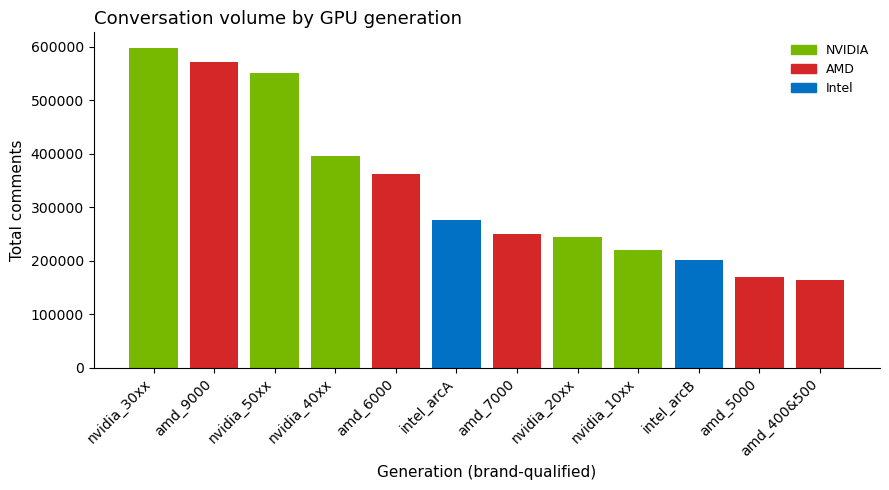

In [14]:
videos_for_gen = videos_df.copy()
if not any(col in videos_for_gen.columns for col in ['generation_sort', 'generation', 'gen', 'gpu_generation']):
    yt_path = ROOT / 'youtube_videos.csv'
    if yt_path.exists():
        yt_meta = pd.read_csv(yt_path)
        join_key = None
        for cand in ['manifest_gpu_model', 'gpu_model']:
            if cand in videos_for_gen.columns:
                join_key = cand
                break
        if join_key and 'GPU_Model' in yt_meta.columns:
            videos_for_gen['__join_key'] = videos_for_gen[join_key].astype(str).str.lower().str.strip()
            yt_meta['__join_key'] = yt_meta['GPU_Model'].astype(str).str.lower().str.strip()
            videos_for_gen = videos_for_gen.merge(
                yt_meta[['__join_key', 'Gen', 'Gen_Sort', 'Brand']],
                on='__join_key', how='left'
            )
            videos_for_gen['generation'] = videos_for_gen.get('Gen_Sort').where(videos_for_gen.get('Gen_Sort').notna(), videos_for_gen.get('Gen'))
            videos_for_gen['generation_sort'] = videos_for_gen.get('Gen_Sort')
            if 'brand' in videos_for_gen.columns:
                videos_for_gen['brand'] = videos_for_gen['brand'].fillna(videos_for_gen.get('Brand'))
            videos_for_gen = videos_for_gen.drop(columns=['__join_key', 'Gen', 'Gen_Sort', 'Brand'], errors='ignore')

gen_label_col = None
for cand in ['generation_sort', 'generation', 'gen', 'gpu_generation']:
    if cand in videos_for_gen.columns:
        gen_label_col = cand
        break

brand_col = None
for cand in ['manifest_brand', 'brand']:
    if cand in videos_for_gen.columns:
        brand_col = cand
        break

if gen_label_col is None:
    print('No generation column found; skipping generation-level chart.')
else:
    comment_counts_by_video = comments_df.groupby('video_id').size().rename('total_comments')
    videos_with_comments = videos_for_gen[['video_id']].copy()
    videos_with_comments['generation_group'] = videos_for_gen[gen_label_col]
    if brand_col:
        videos_with_comments['brand'] = videos_for_gen[brand_col]
    videos_with_comments = videos_with_comments.join(comment_counts_by_video, on='video_id')
    videos_with_comments['total_comments'] = videos_with_comments['total_comments'].fillna(0)

    gen_group_df = (videos_with_comments.dropna(subset=['generation_group'])
                    .groupby('generation_group')
                    .agg(gen_total_comments=('total_comments', 'sum'),
                         gen_num_videos=('video_id', 'nunique'))
                    .reset_index())
    if brand_col:
        brand_mode = (videos_with_comments.dropna(subset=['generation_group'])
                      .groupby('generation_group')['brand']
                      .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None)
                      .rename('brand'))
        gen_group_df = gen_group_df.merge(brand_mode, on='generation_group', how='left')

    gen_group_df = gen_group_df.sort_values('gen_total_comments', ascending=False)

    color_map = {'nvidia': '#76b900', 'amd': '#d62728', 'intel': '#0071c5'}
    gen_group_df['brand_clean'] = gen_group_df['brand'].str.lower() if 'brand' in gen_group_df.columns else ''
    gen_group_df['bar_color'] = gen_group_df['brand_clean'].map(color_map).fillna('gray') if 'brand_clean' in gen_group_df.columns else 'steelblue'

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(gen_group_df['generation_group'], gen_group_df['gen_total_comments'], color=gen_group_df['bar_color'])
    ax.set_title('Conversation volume by GPU generation', fontsize=13, loc='left')
    ax.set_xlabel('Generation (brand-qualified)', fontsize=11)
    ax.set_ylabel('Total comments', fontsize=11)
    ax.tick_params(axis='x', labelsize=10, labelrotation=45)
    ax.tick_params(axis='y', labelsize=10)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    if brand_col:
        legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map['nvidia'], label='NVIDIA'),
                          plt.Rectangle((0, 0), 1, 1, color=color_map['amd'], label='AMD'),
                          plt.Rectangle((0, 0), 1, 1, color=color_map['intel'], label='Intel')]
        ax.legend(handles=legend_handles, frameon=False, fontsize=9, loc='upper right')

    fig.tight_layout()
    fig.savefig(FIG_DIR / 'comments_by_generation_grouped.png', dpi=150)
    plt.show()

In [15]:
comment_words = comments_df['text'].fillna('').str.split().str.len()
base_segment_duration = transcript_duration if 'transcript_duration' in locals() else (transcripts_df['end_seconds'].fillna(0) - transcripts_df['start_seconds'].fillna(0)).clip(lower=0)
segment_duration = base_segment_duration
comment_len_median = float(comment_words.median())
comment_len_p95 = float(comment_words.quantile(0.95))
segment_median = float(segment_duration.median())
segment_p95 = float(segment_duration.quantile(0.95))

monthly_msg = "Comments per month (proxied by video upload date)" if 'monthly_comments' in locals() and not monthly_comments.empty else "No proxy month data to plot"

if 'agg_gen_top' in locals() and hasattr(agg_gen_top, 'empty') and not agg_gen_top.empty:
    top_row = agg_gen_top.iloc[0]
    brand = top_row['brand'] if 'brand' in top_row else None
    brand_part = f" ({brand})" if pd.notna(brand) and brand not in (None, '') else ""
    top_models_brief = f"Top model by comments: {top_row['group']}{brand_part}, comments={int(top_row['gen_total_comments'])}."
else:
    top_models_brief = "GPU models: aggregation computed; see tables/plots for leaders."

if 'gen_group_df' in locals() and hasattr(gen_group_df, 'empty') and not gen_group_df.empty:
    top_gen = gen_group_df.iloc[0]
    brand = top_gen['brand'] if 'brand' in top_gen else None
    brand_part = f" ({brand})" if pd.notna(brand) and brand not in (None, '') else ""
    gen_brief = f"Top generation/group: {top_gen['generation_group']}{brand_part} with {int(top_gen['gen_total_comments'])} comments."
else:
    gen_brief = "Generation/group summary not available."

word_share = corpus_df.groupby('source_type')['text'].apply(approx_word_count).reset_index(name='total_words')
word_share = word_share.sort_values('total_words', ascending=False)
word_share_lines = ', '.join([f"{row.source_type}: {row.total_words:,}" for row in word_share.itertuples(index=False)])

summary_lines = [
    f"Comment lengths: median ~{comment_len_median:.0f} words; 95th pct ~{comment_len_p95:.0f} words.",
    f"Transcript segment durations: median ~{segment_median:.1f}s; 95th pct ~{segment_p95:.1f}s.",
    f"Time evolution: {monthly_msg}.",
    top_models_brief,
    gen_brief,
    f"Word share (comments vs transcripts): {word_share_lines}.",
]

summary_md = '\n'.join([f"- {line}" for line in summary_lines])
display(Markdown(summary_md))

- Comment lengths: median ~16 words; 95th pct ~83 words.
- Transcript segment durations: median ~1.0s; 95th pct ~3.0s.
- Time evolution: Comments per month (proxied by video upload date).
- Top model by comments: Radeon RX 9070 XT (AMD), comments=31276.
- Top generation/group: nvidia_30xx (NVIDIA) with 596859 comments.
- Word share (comments vs transcripts): comment: 20,420,835, transcript: 3,219,211.

In [16]:
yt_path = ROOT / 'youtube_videos.csv'
if yt_path.exists():
    yt_meta = pd.read_csv(yt_path)
    join_key = 'manifest_gpu_model' if 'manifest_gpu_model' in videos_df.columns else 'gpu_model'
    if join_key in videos_df.columns and 'GPU_Model' in yt_meta.columns:
        videos_df['__join_key'] = videos_df[join_key].astype(str).str.lower().str.strip()
        yt_meta['__join_key'] = yt_meta['GPU_Model'].astype(str).str.lower().str.strip()
        videos_df = videos_df.merge(
            yt_meta[['__join_key', 'Gen', 'Gen_Sort', 'Brand']],
            on='__join_key', how='left'
        )
        videos_df['generation'] = videos_df['Gen_Sort'].where(videos_df['Gen_Sort'].notna(), videos_df.get('Gen'))
        videos_df['generation_sort'] = videos_df.get('Gen_Sort')
        if 'brand' in videos_df.columns:
            videos_df['brand'] = videos_df['brand'].fillna(videos_df.get('Brand'))
        videos_df = videos_df.drop(columns=['__join_key', 'Gen', 'Gen_Sort', 'Brand'], errors='ignore')
        print('Merged generation info from youtube_videos.csv (using Gen_Sort for labels when available)')
    else:
        print('youtube_videos.csv present but missing expected columns for merge')
else:
    print('youtube_videos.csv not found; skipping generation enrichment')

Merged generation info from youtube_videos.csv (using Gen_Sort for labels when available)


## Stage 3 - Sentiment and aspect flags

In [17]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

In [18]:
sent_df = corpus_df.copy()

sent_df = sent_df[sent_df['source_type'].isin(['comment', 'transcript'])]
sent_df['text'] = sent_df['text'].fillna('')
sent_df = sent_df[sent_df['text'].str.strip().ne('')]

video_cols = ['video_id']
for cand in ['manifest_gpu_model', 'gpu_model']:
    if cand in videos_df.columns:
        video_cols.append(cand)
        break
for cand in ['manifest_brand', 'brand']:
    if cand in videos_df.columns:
        video_cols.append(cand)
        break
for cand in ['publish_date_utc', 'upload_date', 'release_timestamp', 'timestamp', 'timestamp_utc']:
    if cand in videos_df.columns:
        video_cols.append(cand)
        break

videos_info = videos_df[video_cols].drop_duplicates('video_id')
sent_df = sent_df.merge(videos_info, on='video_id', how='left')

gpu_model_col = 'manifest_gpu_model' if 'manifest_gpu_model' in sent_df.columns else ('gpu_model' if 'gpu_model' in sent_df.columns else None)
brand_col = 'manifest_brand' if 'manifest_brand' in sent_df.columns else ('brand' if 'brand' in sent_df.columns else None)
publish_col = None
for cand in ['publish_date_utc', 'upload_date', 'release_timestamp', 'timestamp', 'timestamp_utc']:
    if cand in sent_df.columns:
        publish_col = cand
        break

sent_df['gpu_model'] = sent_df[gpu_model_col] if gpu_model_col else None
sent_df['brand'] = sent_df[brand_col] if brand_col else None
sent_df['publish_date_utc'] = sent_df[publish_col] if publish_col else None
sent_df['month'] = safe_month_floor(sent_df['publish_date_utc']) if publish_col else pd.NaT

if 'doc_id' not in sent_df.columns:
    sent_df['doc_id'] = sent_df.index

keep_cols = ['doc_id', 'video_id', 'source_type', 'gpu_model', 'brand', 'publish_date_utc', 'month', 'text']
if 'lang' in sent_df.columns:
    keep_cols.append('lang')
sent_df = sent_df[keep_cols]
print(f"Working docs for sentiment: {len(sent_df):,}")
print(sent_df['source_type'].value_counts())

Working docs for sentiment: 1,070,336
source_type
comment       762642
transcript    307694
Name: count, dtype: int64


In [19]:

def label_sentiment(compound):
    if compound <= -0.05:
        return 'neg'
    if compound >= 0.05:
        return 'pos'
    return 'neu'

sent_df['sentiment_compound'] = sent_df['text'].apply(lambda t: sia.polarity_scores(t)['compound'])
sent_df['sentiment_label'] = sent_df['sentiment_compound'].apply(label_sentiment)
print(sent_df[['sentiment_compound', 'sentiment_label']].head())

   sentiment_compound sentiment_label
0              0.0000             neu
1             -0.1540             neg
2              0.2500             pos
3              0.5258             pos
4             -0.3612             neg


In [20]:
aspect_keywords = {
    'price_value': ['price', 'value', 'worth', 'expensive', 'cheap', 'overpriced', 'deal', 'bargain', 'cost', 'costly', 'affordable', 'money', 'budget', 'pricing', 'retail', 'msrp', 'sale', 'discount'],
    'performance': ['fps', 'benchmarks', 'benchmark', 'perf', 'frames', 'bottleneck', 'slow', 'lag', 'stutter', 'smooth', 'fps drops', 'performance', 'frame rate'],
    'drivers': ['driver', 'drivers', 'update', 'bug', 'crash', 'driver issue', 'broken drivers', 'updated driver', 'bugs', 'stability', 'compatibility'],
    'vram': ['vram', 'memory', '8gb', '10gb', '12gb', '16gb', '6gb', '24gb', 'memory buffer', 'video memory', 'ram', 'gddr6', 'gddr5', 'vram usage', 'memory usage'],
    'thermals_noise': ['temp', 'thermal', 'fan', 'noise', 'hot', 'cool', 'overheat', 'overheating', 'cooler', 'fan noise', 'thermals', 'quiet', 'loud', 'thermals', 'temperature', 'cooling'],
    'coil_whine': ['coil whine', 'coil-whine'],
}

text_lower = sent_df['text'].str.lower()
for aspect, keywords in aspect_keywords.items():
    sent_df[f'aspect_{aspect}'] = text_lower.apply(lambda x: any(k in x for k in keywords))

aspect_cols = [c for c in sent_df.columns if c.startswith('aspect_')]
print('Aspect columns added:', aspect_cols)

Aspect columns added: ['aspect_price_value', 'aspect_performance', 'aspect_drivers', 'aspect_vram', 'aspect_thermals_noise', 'aspect_coil_whine']


In [21]:
feature_keywords = {
    'feature_upscaling': ['dlss', 'fsr', 'xess', 'xess', 'dlss 2', 'dlss2', 'fsr 2', 'fsr2', 'fsr 3', 'fsr3', 'image upscaling', 'dlss 4', 'dlss 3', 'dlss3', 'dlss4', 'upscaling'],
    'feature_ray_tracing': ['ray tracing', 'ray-tracing', 'rtx on', 'path tracing', 'path-tracing', 'rt reflections', 'rt shadows', 'raytracing'],
    'feature_frame_gen': ['frame gen', 'frame-gen', 'frame generation', 'dlss 3', 'dlss3', 'frame interpolation', 'afmf', 'ai frame generation', 'ai frame gen'],
}

for feat, keywords in feature_keywords.items():
    sent_df[feat] = text_lower.apply(lambda x: any(k in x for k in keywords))

feature_cols = [c for c in sent_df.columns if c.startswith('feature_')]
print('Feature columns added:', feature_cols)

Feature columns added: ['feature_upscaling', 'feature_ray_tracing', 'feature_frame_gen']


In [22]:
mining_keywords = ['mining', 'miner', 'mine ethereum', 'ethereum', 'eth', 'crypto', 'hashrate', 'hash rate', 'lhr', 'mining performance',
                   'ethereum mining', 'cryptocurrency', 'mining rig', 'mining profitability', 'mining efficiency',]
sent_df['mining_flag'] = text_lower.apply(lambda x: any(k in x for k in mining_keywords))
print('Mining flag added')

Mining flag added


In [23]:
analysis_dir = Path('data-processed') / 'analysis'
analysis_dir.mkdir(parents=True, exist_ok=True)

aspect_cols = [c for c in sent_df.columns if c.startswith('aspect_')]
feature_cols = [c for c in sent_df.columns if c.startswith('feature_')]
extra_cols = aspect_cols + feature_cols
if 'mining_flag' in sent_df.columns:
    extra_cols.append('mining_flag')

cols_to_keep = ['doc_id', 'video_id', 'source_type', 'gpu_model', 'brand', 'publish_date_utc', 'month', 'text', 'sentiment_compound', 'sentiment_label'] + extra_cols
if 'lang' in sent_df.columns:
    cols_to_keep.insert(3, 'lang')

sent_docs_out = sent_df[cols_to_keep]
output_docs_path = analysis_dir / 'docs_with_sentiment.parquet'
sent_docs_out.to_parquet(output_docs_path, index=False)
print(f"Wrote {len(sent_docs_out):,} docs to {output_docs_path}")

Wrote 1,070,336 docs to data-processed\analysis\docs_with_sentiment.parquet


In [24]:
group_cols = ['month', 'gpu_model', 'source_type']
grouped = sent_df.groupby(group_cols)

agg_df = grouped.agg(
    num_docs=('text', 'size'),
    mean_sentiment=('sentiment_compound', 'mean'),
    share_pos=('sentiment_label', lambda s: (s == 'pos').mean()),
    share_neg=('sentiment_label', lambda s: (s == 'neg').mean()),
    share_neu=('sentiment_label', lambda s: (s == 'neu').mean()),
)

for aspect in [c for c in sent_df.columns if c.startswith('aspect_')]:
    agg_df[f'{aspect}_share'] = grouped[aspect].mean()

agg_df = agg_df.reset_index()
output_agg_path = analysis_dir / 'monthly_sentiment_by_model.parquet'
agg_df.to_parquet(output_agg_path, index=False)
print(f"Wrote {len(agg_df):,} rows to {output_agg_path}")

Wrote 270 rows to data-processed\analysis\monthly_sentiment_by_model.parquet


In [25]:
print('Docs with sentiment (head):')
print(sent_docs_out.head())
print('\nMonthly sentiment by model (head):')
print(agg_df.head())

print('\nSummary:')
print(f"Total docs scored: {len(sent_docs_out):,}")
if not sent_docs_out.empty:
    print('Mean compound by source_type:')
    print(sent_docs_out.groupby('source_type')['sentiment_compound'].mean())
    top_models = sent_docs_out.dropna(subset=['gpu_model']).groupby('gpu_model').size().sort_values(ascending=False).head(5)
    print('\nTop 5 GPU models by scored docs:')
    print(top_models)
else:
    print('No docs scored.')

Docs with sentiment (head):
   doc_id     video_id source_type  lang          gpu_model brand          publish_date_utc      month                                               text  \
0       0  -LAH5vh-Cpg     comment  None  Radeon RX 9060 XT   AMD 2025-06-04 00:00:00+00:00 2025-06-01                                                 👍🖖   
1       1  -LAH5vh-Cpg     comment  None  Radeon RX 9060 XT   AMD 2025-06-04 00:00:00+00:00 2025-06-01  After having my 9060xt 16gb I'm very happy wit...   
2       2  -LAH5vh-Cpg     comment  None  Radeon RX 9060 XT   AMD 2025-06-04 00:00:00+00:00 2025-06-01  For the cost per frame don’t u want lower is b...   
3       3  -LAH5vh-Cpg     comment  None  Radeon RX 9060 XT   AMD 2025-06-04 00:00:00+00:00 2025-06-01  I just got my 9060xt after going back and fort...   
4       4  -LAH5vh-Cpg     comment  None  Radeon RX 9060 XT   AMD 2025-06-04 00:00:00+00:00 2025-06-01  If you bought the 8gb version in 2025, slap yo...   

   sentiment_compound sentime

## Stage 4 - Sentiment overview and per-generation patterns

In [26]:
from pathlib import Path
analysis_dir = Path('data-processed') / 'analysis'
if 'sent_docs_out' not in globals():
    docs_path = analysis_dir / 'docs_with_sentiment.parquet'
    sent_docs_out = pd.read_parquet(docs_path)
if 'agg_df' not in globals():
    agg_path = analysis_dir / 'monthly_sentiment_by_model.parquet'
    agg_df = pd.read_parquet(agg_path)
print(f"Docs with sentiment: {len(sent_docs_out):,}; monthly agg rows: {len(agg_df):,}")

Docs with sentiment: 1,070,336; monthly agg rows: 270


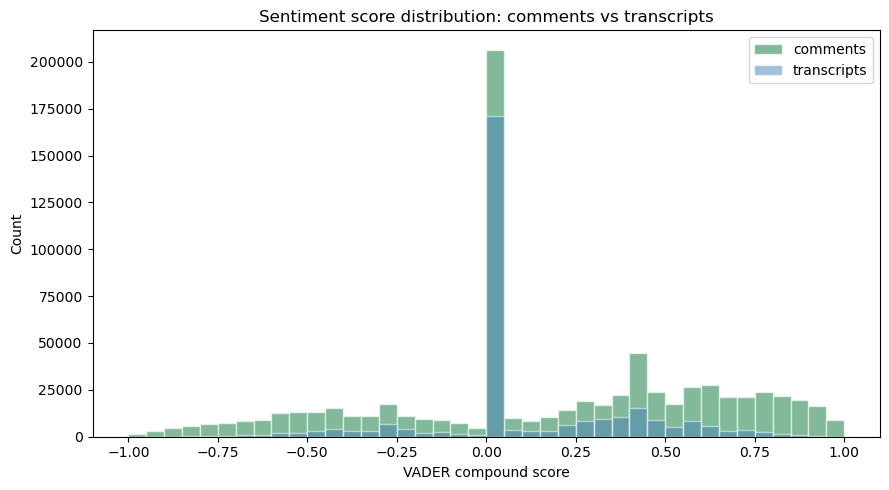

  source_type      mean  median  share_neg  share_neu  share_pos
0     comment  0.165094     0.0   0.231064   0.277025   0.491911
1  transcript  0.094367     0.0   0.120981   0.558422   0.320598


In [27]:
comments_sent = sent_docs_out[sent_docs_out['source_type'] == 'comment']
transcripts_sent = sent_docs_out[sent_docs_out['source_type'] == 'transcript']

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(comments_sent['sentiment_compound'], bins=40, range=(-1, 1), alpha=0.6, label='comments', color='seagreen', edgecolor='white')
ax.hist(transcripts_sent['sentiment_compound'], bins=40, range=(-1, 1), alpha=0.5, label='transcripts', color='steelblue', edgecolor='white')
ax.set_title('Sentiment score distribution: comments vs transcripts')
ax.set_xlabel('VADER compound score')
ax.set_ylabel('Count')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'sentiment_dist_comments_vs_transcripts.png', dpi=150)
plt.show()

summary_rows = []
for name, df in [('comment', comments_sent), ('transcript', transcripts_sent)]:
    if df.empty:
        summary_rows.append({'source_type': name, 'mean': None, 'median': None, 'share_neg': None, 'share_neu': None, 'share_pos': None})
        continue
    summary_rows.append({
        'source_type': name,
        'mean': df['sentiment_compound'].mean(),
        'median': df['sentiment_compound'].median(),
        'share_neg': (df['sentiment_label'] == 'neg').mean(),
        'share_neu': (df['sentiment_label'] == 'neu').mean(),
        'share_pos': (df['sentiment_label'] == 'pos').mean(),
    })
summary_table = pd.DataFrame(summary_rows)
print(summary_table)

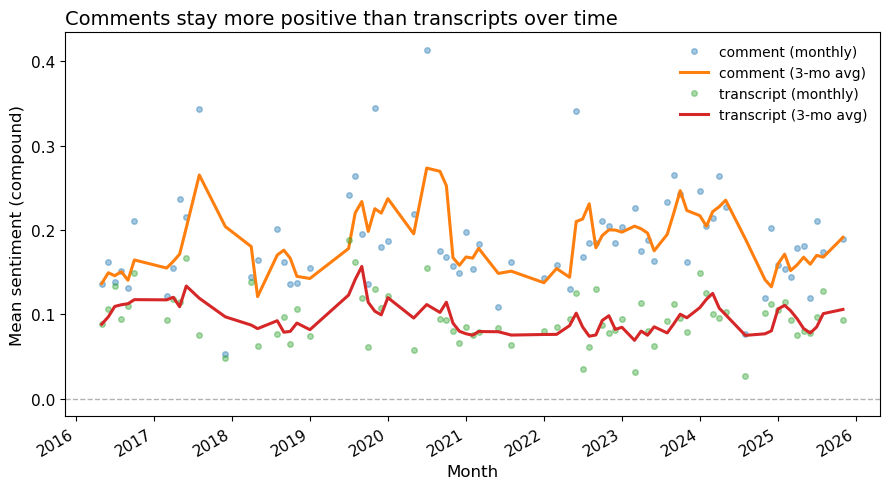

In [28]:
time_group = agg_df.groupby(['month', 'source_type']).agg(mean_sentiment=('mean_sentiment', 'mean'), num_docs=('num_docs', 'sum')).reset_index()
time_group = time_group.sort_values('month')
time_group['rolling_mean'] = (time_group.groupby('source_type')['mean_sentiment']
                             .transform(lambda s: s.rolling(3, min_periods=1).mean()))

fig, ax = plt.subplots(figsize=(9, 5))
for stype, grp in time_group.groupby('source_type'):
    ax.plot(grp['month'], grp['mean_sentiment'], marker='o', markersize=4, alpha=0.4, linestyle='none', label=f"{stype} (monthly)")
    ax.plot(grp['month'], grp['rolling_mean'], linewidth=2.2, label=f"{stype} (3-mo avg)")
ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_title('Comments stay more positive than transcripts over time', fontsize=14, loc='left')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Mean sentiment (compound)', fontsize=12)
ax.tick_params(labelsize=11)
ax.legend(frameon=False, fontsize=10)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / 'sentiment_over_time_by_source.png', dpi=150)
plt.show()

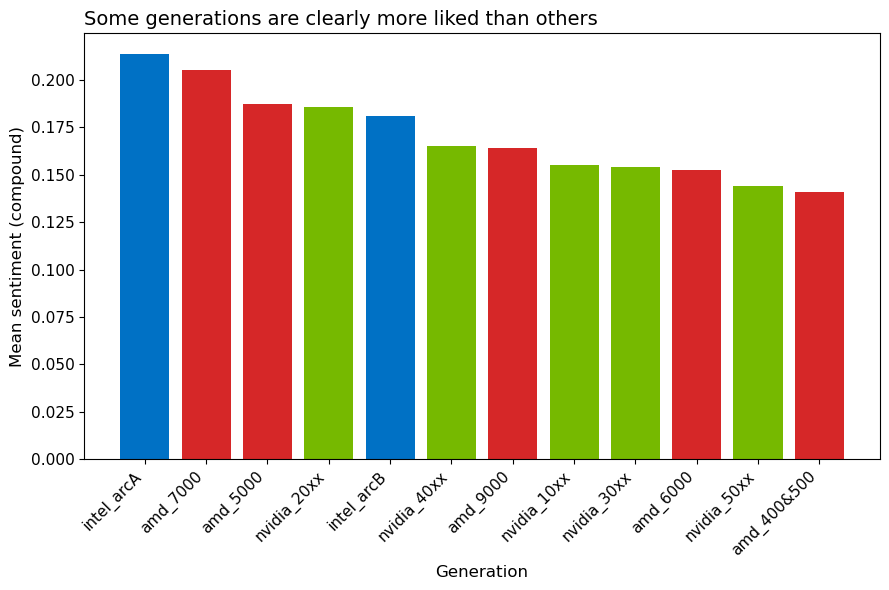

Generation sentiment stats:
     generation  num_docs  mean_sentiment  share_pos  share_neg
5    intel_arcA     40742        0.214004   0.539272   0.200579
3      amd_7000     49924        0.205411   0.539260   0.223500
1      amd_5000     28114        0.187450   0.500605   0.206872
8   nvidia_20xx     57039        0.185564   0.505163   0.216220
6    intel_arcB     22359        0.181062   0.506105   0.218838
10  nvidia_40xx     99176        0.165426   0.507381   0.253711
4      amd_9000     63069        0.164287   0.493602   0.236122
7   nvidia_10xx     44113        0.155048   0.462426   0.212069
9   nvidia_30xx    132637        0.154121   0.468120   0.218295
2      amd_6000     72273        0.152562   0.487803   0.243895
11  nvidia_50xx    112402        0.144214   0.481166   0.255084
0   amd_400&500     40794        0.140847   0.460264   0.225156


In [29]:
comments_sent = sent_docs_out[sent_docs_out['source_type'] == 'comment'].copy()

if 'generation' in videos_df.columns:
    gen_cols = ['video_id', 'generation', 'generation_sort']
    if 'brand' in videos_df.columns:
        gen_cols.append('brand')
    gen_info = videos_df[gen_cols].drop_duplicates('video_id')
    comments_sent = comments_sent.merge(gen_info, on='video_id', how='left')
    comments_sent['generation'] = comments_sent['generation'].fillna('Unknown')
elif 'gen' in videos_df.columns:
    gen_info = videos_df[['video_id', 'gen']].drop_duplicates('video_id').rename(columns={'gen': 'generation'})
    comments_sent = comments_sent.merge(gen_info, on='video_id', how='left')
    comments_sent['generation'] = comments_sent['generation'].fillna('Unknown')
else:
    comments_sent['generation'] = comments_sent['gpu_model']
    print('No generation column found; using gpu_model as proxy for grouping.')

agg_gen = (comments_sent
           .groupby('generation')
           .agg(num_docs=('sentiment_compound', 'size'),
                mean_sentiment=('sentiment_compound', 'mean'),
                share_pos=('sentiment_label', lambda s: (s == 'pos').mean()),
                share_neg=('sentiment_label', lambda s: (s == 'neg').mean()))
           .reset_index())

if 'brand' in comments_sent.columns:
    brand_mode = (comments_sent.groupby('generation')['brand']
                  .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None)
                  .rename('brand'))
    agg_gen = agg_gen.merge(brand_mode, on='generation', how='left')

if 'generation_sort' in videos_df.columns:
    order = (videos_df[['generation', 'generation_sort']]
             .dropna(subset=['generation_sort'])
             .drop_duplicates()
             .sort_values('generation_sort'))
    order_map = {g: i for i, g in enumerate(order['generation'].tolist())}
    agg_gen['__order'] = agg_gen['generation'].map(order_map)
    agg_gen = agg_gen.sort_values(['mean_sentiment'], ascending=False)
else:
    agg_gen = agg_gen.sort_values('mean_sentiment', ascending=False)

color_map = {'nvidia': '#76b900', 'amd': '#d62728', 'intel': '#0071c5'}
if 'brand' in agg_gen.columns:
    agg_gen['brand_clean'] = agg_gen['brand'].str.lower()
    agg_gen['bar_color'] = agg_gen['brand_clean'].map(color_map).fillna('gray')
else:
    agg_gen['bar_color'] = 'seagreen'

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(agg_gen['generation'], agg_gen['mean_sentiment'], color=agg_gen['bar_color'])
ax.set_title('Some generations are clearly more liked than others', fontsize=14, loc='left')
ax.set_xlabel('Generation', fontsize=12)
ax.set_ylabel('Mean sentiment (compound)', fontsize=12)
ax.tick_params(labelsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'sentiment_by_generation_comments.png', dpi=150)
plt.show()

print('Generation sentiment stats:')
print(agg_gen[['generation', 'num_docs', 'mean_sentiment', 'share_pos', 'share_neg']])

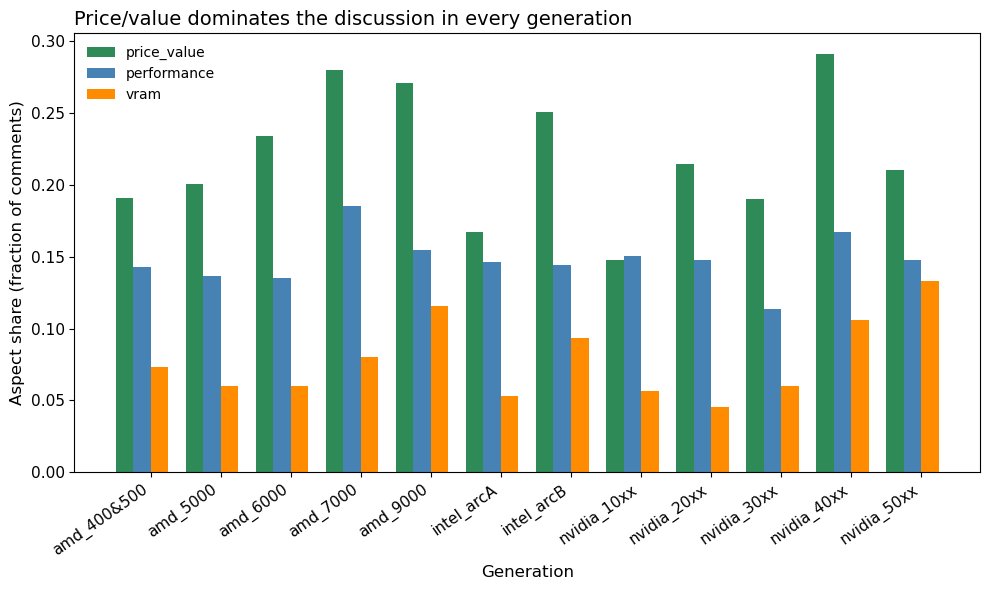

Other aspect shares by generation:
             aspect_drivers  aspect_thermals_noise  aspect_coil_whine
generation                                                           
amd_400&500        0.026107               0.066848           0.000245
amd_5000           0.061962               0.097923           0.000498
amd_6000           0.035878               0.051734           0.001577
amd_7000           0.060051               0.050717           0.005128
amd_9000           0.042921               0.042446           0.000349


In [30]:
comments_sent = sent_docs_out[sent_docs_out['source_type'] == 'comment'].copy()

if 'generation' in videos_df.columns:
    gen_info = videos_df[['video_id', 'generation', 'generation_sort']].drop_duplicates('video_id')
    comments_sent = comments_sent.merge(gen_info, on='video_id', how='left')
    comments_sent['generation'] = comments_sent['generation'].fillna('Unknown')
else:
    comments_sent['generation'] = comments_sent['gpu_model']

core_aspects = ['aspect_price_value', 'aspect_performance', 'aspect_vram']
missing = [c for c in core_aspects if c not in comments_sent.columns]
if missing:
    print('Missing aspects:', missing)
else:
    agg_aspects = comments_sent.groupby('generation')[core_aspects].mean().reset_index()
    if 'generation_sort' in videos_df.columns:
        order = (videos_df[['generation', 'generation_sort']]
                 .dropna(subset=['generation_sort'])
                 .drop_duplicates()
                 .sort_values('generation_sort'))
        order_map = {g: i for i, g in enumerate(order['generation'].tolist())}
        agg_aspects['__order'] = agg_aspects['generation'].map(order_map)
        agg_aspects = agg_aspects.sort_values(['__order', 'generation'])
        agg_aspects = agg_aspects.drop(columns='__order')
    else:
        agg_aspects = agg_aspects.sort_values('generation')

    fig, ax = plt.subplots(figsize=(10, 6))
    bar_width = 0.25
    x = range(len(agg_aspects))
    colors = ['seagreen', 'steelblue', 'darkorange']
    for idx, aspect in enumerate(core_aspects):
        offsets = [xi + (idx - len(core_aspects)/2)*bar_width for xi in x]
        ax.bar(offsets, agg_aspects[aspect], width=bar_width, label=aspect.replace('aspect_', ''), color=colors[idx % len(colors)])
    ax.set_title('Price/value dominates the discussion in every generation', fontsize=14, loc='left')
    ax.set_xlabel('Generation', fontsize=12)
    ax.set_ylabel('Aspect share (fraction of comments)', fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(agg_aspects['generation'], rotation=35, ha='right')
    ax.tick_params(labelsize=11)
    ax.legend(frameon=False, fontsize=10, loc='upper left')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'aspects_by_generation_core_comments.png', dpi=150)
    plt.show()

    other_aspects = [c for c in comments_sent.columns if c.startswith('aspect_') and c not in core_aspects]
    if other_aspects:
        other_summary = comments_sent.groupby('generation')[other_aspects].mean()
        print('Other aspect shares by generation:')
        print(other_summary.head())

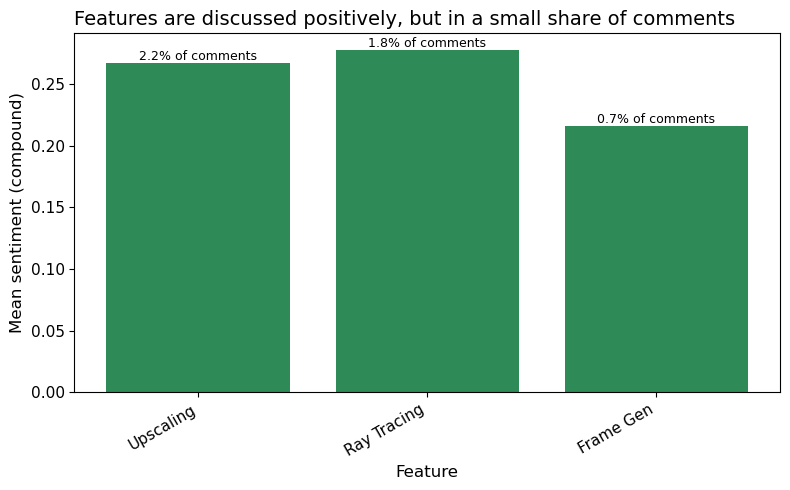

       feature  num_docs_feature  share_of_comments  mean_sentiment_feature
0    Upscaling             16838           0.022079                0.266718
1  Ray Tracing             14083           0.018466                0.277038
2    Frame Gen              5220           0.006845                0.216178


In [36]:
comments_only = sent_docs_out[sent_docs_out['source_type'] == 'comment'].copy()
feature_cols = [c for c in comments_only.columns if c.startswith('feature_')]

rows = []
for feat in feature_cols:
    num = comments_only[feat].sum()
    share = num / len(comments_only) if len(comments_only) else 0
    mean_sent = comments_only.loc[comments_only[feat], 'sentiment_compound'].mean() if num > 0 else np.nan
    rows.append({'feature': feat.replace('feature_', '').replace('_', ' ').title(),
                 'num_docs_feature': int(num),
                 'share_of_comments': share,
                 'mean_sentiment_feature': mean_sent})
feature_summary_df = pd.DataFrame(rows)
feature_summary_df = feature_summary_df.sort_values('num_docs_feature', ascending=False)

analysis_dir = Path('data-processed') / 'analysis'
feature_summary_df.to_parquet(analysis_dir / 'feature_sentiment_overall.parquet', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(feature_summary_df['feature'], feature_summary_df['mean_sentiment_feature'], color='seagreen')
ax.set_title('Features are discussed positively, but in a small share of comments', fontsize=14, loc='left')
ax.set_ylabel('Mean sentiment (compound)', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
ax.tick_params(labelsize=11)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
for idx, row in feature_summary_df.iterrows():
    ax.text(idx, row['mean_sentiment_feature'] + 0, f"{row['share_of_comments']*100:.1f}% of comments", ha='center', va='bottom', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'feature_sentiment_overall_comments.png', dpi=150)
plt.show()

print(feature_summary_df)

C:\Users\Matthew\AppData\Local\Temp\ipykernel_10928\1187711443.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mining_summary = gen_group.apply(lambda df: pd.Series({


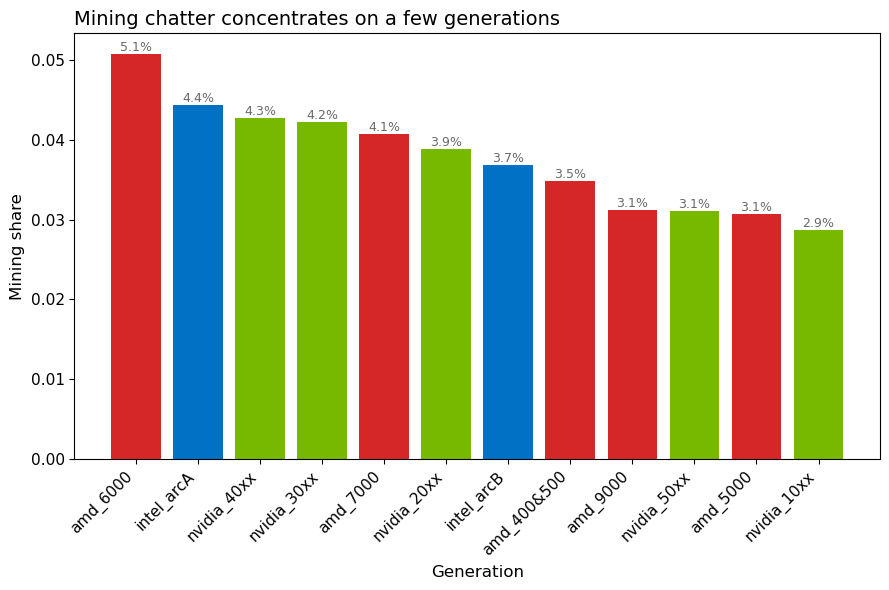

    generation  gen_total_comments  gen_mining_comments  mining_share  mean_sentiment_mining   brand brand_clean bar_color
0     amd_6000             72273.0               3673.0      0.050821               0.181111     AMD         amd   #d62728
1   intel_arcA             40742.0               1810.0      0.044426               0.321904   INTEL       intel   #0071c5
2  nvidia_40xx             99176.0               4243.0      0.042783               0.196432  NVIDIA      nvidia   #76b900
3  nvidia_30xx            132637.0               5605.0      0.042258               0.182531  NVIDIA      nvidia   #76b900
4     amd_7000             49924.0               2035.0      0.040762               0.282235     AMD         amd   #d62728


In [32]:
comments_only = sent_docs_out[sent_docs_out['source_type'] == 'comment'].copy()
if 'generation' in videos_df.columns:
    gen_cols = ['video_id', 'generation', 'generation_sort']
    if 'brand' in videos_df.columns:
        gen_cols.append('brand')
    gen_info = videos_df[gen_cols].drop_duplicates('video_id')
    comments_only = comments_only.merge(gen_info, on='video_id', how='left')
    comments_only['generation'] = comments_only['generation'].fillna('Unknown')
else:
    comments_only['generation'] = comments_only['gpu_model']

if 'mining_flag' not in comments_only.columns:
    comments_only['mining_flag'] = False

gen_group = comments_only.groupby('generation')
mining_summary = gen_group.apply(lambda df: pd.Series({
    'gen_total_comments': len(df),
    'gen_mining_comments': df['mining_flag'].sum(),
    'mining_share': df['mining_flag'].mean() if len(df) else 0,
    'mean_sentiment_mining': df.loc[df['mining_flag'], 'sentiment_compound'].mean() if df['mining_flag'].any() else np.nan,
})).reset_index()

mining_summary = mining_summary.sort_values('mining_share', ascending=False)

if 'brand' in comments_only.columns:
    brand_mode = (comments_only.groupby('generation')['brand']
                  .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None)
                  .rename('brand'))
    mining_summary = mining_summary.merge(brand_mode, on='generation', how='left')

color_map = {'nvidia': '#76b900', 'amd': '#d62728', 'intel': '#0071c5'}
if 'brand' in mining_summary.columns:
    mining_summary['brand_clean'] = mining_summary['brand'].str.lower()
    mining_summary['bar_color'] = mining_summary['brand_clean'].map(color_map).fillna('gray')
else:
    mining_summary['bar_color'] = 'steelblue'

analysis_dir = Path('data-processed') / 'analysis'
mining_summary.to_parquet(analysis_dir / 'mining_by_generation_comments.parquet', index=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(mining_summary['generation'], mining_summary['mining_share'], color=mining_summary['bar_color'])
ax.set_title('Mining chatter concentrates on a few generations', fontsize=14, loc='left')
ax.set_xlabel('Generation', fontsize=12)
ax.set_ylabel('Mining share', fontsize=12)
ax.tick_params(labelsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
for i, row in mining_summary.iterrows():
    ax.text(i, row['mining_share'] + 0, f"{row['mining_share']*100:.1f}%", ha='center', va='bottom', fontsize=9, color='dimgray')
fig.tight_layout()
fig.savefig(FIG_DIR / 'mining_share_by_generation_comments.png', dpi=150)
plt.show()

print(mining_summary.head())

#### Mining flag note
- `mining_flag` is a simple keyword-based tag (e.g., mining, ethereum, crypto, hashrate, lhr).
- Current view shows mining-related comment share by generation; deeper time/model cuts can follow later.

## Stage 6 - Creator vs crowd and mining over time

C:\Users\Matthew\AppData\Local\Temp\ipykernel_10928\3083457707.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = joined.groupby(['generation', 'source_type']).apply(


Saved creator/crowd table: 12


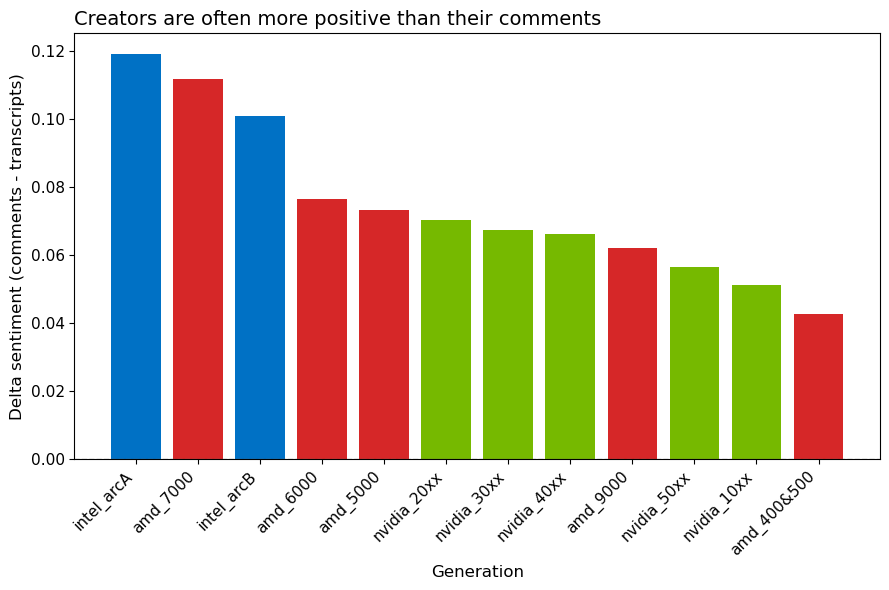

In [33]:
analysis_dir = Path('data-processed') / 'analysis'

if 'sent_docs_out' not in globals():
    sent_docs_out = pd.read_parquet(analysis_dir / 'docs_with_sentiment.parquet')

gen_join_cols = ['video_id']
if 'generation' in videos_df.columns:
    gen_join_cols.append('generation')
if 'generation_sort' in videos_df.columns:
    gen_join_cols.append('generation_sort')
if 'brand' in videos_df.columns:
    gen_join_cols.append('brand')
if 'gpu_model' in videos_df.columns:
    gen_join_cols.append('gpu_model')
if 'manifest_gpu_model' in videos_df.columns and 'gpu_model' not in gen_join_cols:
    gen_join_cols.append('manifest_gpu_model')

videos_info = videos_df[gen_join_cols].drop_duplicates('video_id')
joined = sent_docs_out.merge(videos_info, on='video_id', how='left')
joined['generation'] = joined.get('generation').fillna('Unknown') if 'generation' in joined.columns else 'Unknown'

core_aspects = ['aspect_price_value', 'aspect_performance', 'aspect_vram']

agg = joined.groupby(['generation', 'source_type']).apply(
    lambda df: pd.Series({
        'num_docs': len(df),
        'mean_sentiment': df['sentiment_compound'].mean(),
        **{f"{a}_share": df[a].mean() for a in core_aspects if a in df.columns}
    })
).reset_index()

pivot_mean = agg.pivot(index='generation', columns='source_type', values='mean_sentiment').rename(columns={'comment': 'mean_sentiment_comments', 'transcript': 'mean_sentiment_transcripts'})
pivot_docs = agg.pivot(index='generation', columns='source_type', values='num_docs').rename(columns={'comment': 'num_comments', 'transcript': 'num_transcripts'})

aspect_shares = {}
for a in core_aspects:
    if a + '_share' in agg.columns:
        aspect_shares[a] = agg.pivot(index='generation', columns='source_type', values=f"{a}_share")

creator_crowd_df = pivot_mean.join(pivot_docs)
for a, df_a in aspect_shares.items():
    creator_crowd_df[f'{a}_share_comments'] = df_a.get('comment')
    creator_crowd_df[f'{a}_share_transcripts'] = df_a.get('transcript')

creator_crowd_df = creator_crowd_df.reset_index()
creator_crowd_df['delta_sentiment'] = creator_crowd_df['mean_sentiment_comments'] - creator_crowd_df['mean_sentiment_transcripts']

if 'brand' in joined.columns:
    brand_mode = (joined.groupby('generation')['brand']
                  .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None)
                  .rename('brand'))
    creator_crowd_df = creator_crowd_df.merge(brand_mode, on='generation', how='left')

if 'generation_sort' in videos_df.columns:
    order = videos_df[['generation', 'generation_sort']].dropna(subset=['generation_sort']).drop_duplicates().sort_values('generation_sort')
    order_map = {g: i for i, g in enumerate(order['generation'].tolist())}
    creator_crowd_df['__order'] = creator_crowd_df['generation'].map(order_map)

creator_crowd_df = creator_crowd_df.sort_values('delta_sentiment', ascending=False)
creator_crowd_df = creator_crowd_df.drop(columns='__order', errors='ignore')

creator_crowd_df.to_parquet(analysis_dir / 'creator_crowd_by_generation.parquet', index=False)
print('Saved creator/crowd table:', len(creator_crowd_df))

color_map = {'nvidia': '#76b900', 'amd': '#d62728', 'intel': '#0071c5'}
if 'brand' in creator_crowd_df.columns:
    creator_crowd_df['brand_clean'] = creator_crowd_df['brand'].str.lower()
    bar_colors = creator_crowd_df['brand_clean'].map(color_map).fillna('steelblue')
else:
    bar_colors = 'steelblue'

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(creator_crowd_df['generation'], creator_crowd_df['delta_sentiment'], color=bar_colors)
ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_title('Creators are often more positive than their comments', fontsize=14, loc='left')
ax.set_xlabel('Generation', fontsize=12)
ax.set_ylabel('Delta sentiment (comments - transcripts)', fontsize=12)
ax.tick_params(labelsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'creator_crowd_gap_by_generation.png', dpi=150)
plt.show()

In [34]:
if 'joined' not in globals():
    print('Joined data not available; run previous cell first.')
else:
    min_comments = 200
    min_transcripts = 100
    counts_comment = joined[joined['source_type']=='comment'].groupby(['generation','gpu_model']).size().rename('num_comments')
    counts_trans = joined[joined['source_type']=='transcript'].groupby(['generation','gpu_model']).size().rename('num_transcripts')
    means_comment = joined[joined['source_type']=='comment'].groupby(['generation','gpu_model'])['sentiment_compound'].mean().rename('mean_comment')
    means_trans = joined[joined['source_type']=='transcript'].groupby(['generation','gpu_model'])['sentiment_compound'].mean().rename('mean_transcript')
    combo = pd.concat([counts_comment, counts_trans, means_comment, means_trans], axis=1).dropna(subset=['mean_comment','mean_transcript'])
    combo = combo[(combo['num_comments']>=min_comments) & (combo['num_transcripts']>=min_transcripts)]
    combo['delta'] = combo['mean_comment'] - combo['mean_transcript']
    top3 = combo.reindex(combo['delta'].abs().sort_values(ascending=False).head(3).index)
    print('Top 3 gen/model by |delta| with sufficient docs:')
    print(top3[['mean_comment','mean_transcript','delta','num_comments','num_transcripts']])

    def sample_entries(df, source_type, n=3):
        subset = df[df['source_type']==source_type].copy()
        subset['abs_sent'] = subset['sentiment_compound'].abs()
        subset = subset.sort_values('abs_sent', ascending=False).head(n)
        return subset[['generation','gpu_model','source_type','sentiment_compound','text']]

    for idx, row in top3.reset_index().iterrows():
        gen, model = row['generation'], row['gpu_model']
        subset = joined[(joined['generation']==gen) & (joined['gpu_model']==model)]
        print('=== {} / {} ==='.format(gen, model))
        print('Comments samples:')
        samples_c = sample_entries(subset, 'comment', n=5)
        for _, r in samples_c.iterrows():
            txt = (r['text'][:240] + '...') if len(r['text'])>240 else r['text']
            print('  [{:.2f}] {}'.format(r['sentiment_compound'], txt))
        print('Transcripts samples:')
        samples_t = sample_entries(subset, 'transcript', n=5)
        for _, r in samples_t.iterrows():
            txt = (r['text'][:240] + '...') if len(r['text'])>240 else r['text']
            print('  [{:.2f}] {}'.format(r['sentiment_compound'], txt))

Top 3 gen/model by |delta| with sufficient docs:
                              mean_comment  mean_transcript     delta  num_comments  num_transcripts
generation gpu_model                                                                                
intel_arcA Arc A750               0.236089         0.089791  0.146298         13588             4933
amd_7000   Radeon RX 7700 XT      0.242869         0.111744  0.131125          5940             4887
           Radeon RX 7600 XT      0.210036         0.078975  0.131061          7652             4671
=== intel_arcA / Arc A750 ===
Comments samples:
  [1.00] if you had "failed to tell us about your sponsor" i wouldnt have clicked away super fast, but you actually did. At least you usually wait until the end of the video. 99% of your videos i instantly click out/close the tab immediately right w...
  [1.00] Yeah, when Intel stars adding a more diverse cooler, backplate, and colors, then I might buy them.
Yes, none of those are legitimate rea

C:\Users\Matthew\AppData\Local\Temp\ipykernel_10928\2152841326.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_mining = comments_mining.groupby('month').apply(lambda df: pd.Series({


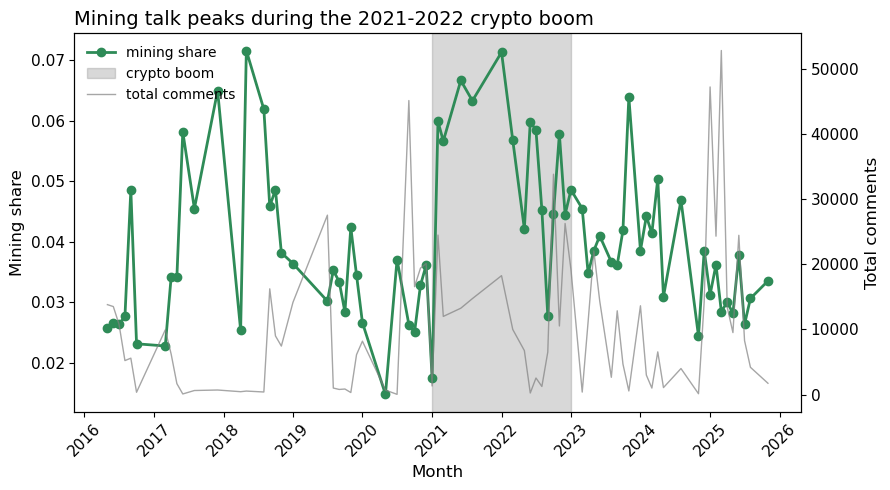

In [44]:
analysis_dir = Path('data-processed') / 'analysis'
if 'sent_docs_out' not in globals():
    sent_docs_out = pd.read_parquet(analysis_dir / 'docs_with_sentiment.parquet')

comments_mining = sent_docs_out[sent_docs_out['source_type']=='comment'].copy()
comments_mining['month'] = safe_month_floor(comments_mining['publish_date_utc'])
monthly_mining = comments_mining.groupby('month').apply(lambda df: pd.Series({
    'total_comments': len(df),
    'mining_comments': df['mining_flag'].sum(),
    'mining_share': df['mining_flag'].mean() if len(df) else 0,
})).reset_index()

analysis_dir.mkdir(parents=True, exist_ok=True)
monthly_mining.to_parquet(analysis_dir / 'mining_over_time_comments.parquet', index=False)

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(monthly_mining['month'], monthly_mining['mining_share'], marker='o', color='seagreen', label='mining share', linewidth=2)
ax1.set_title('Mining talk peaks during the 2021-2022 crypto boom', fontsize=14, loc='left')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Mining share', fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
ax1.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'), color='gray', alpha=0.3, label='crypto boom')

ax2 = ax1.twinx()
ax2.plot(monthly_mining['month'], monthly_mining['total_comments'], color='grey', alpha=0.7, label='total comments', linewidth=1)
ax2.set_ylabel('Total comments', fontsize=12)
ax2.tick_params(labelsize=11)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc='upper left', frameon=False, fontsize=10)

fig.tight_layout()
fig.savefig(FIG_DIR / 'mining_share_over_time_comments.png', dpi=150)
plt.show()

### Stage 6 summary
- Creator vs crowd: delta sentiment by generation highlights where comment tone diverges from transcript tone.
- Generations now reflect brand-qualified labels; largest gaps point to follow-up case studies.
- Mining share over time shows how crypto chatter shifts by upload month (watch for RTX 30-era spikes).
